In [1]:
import pandas as pd
import numpy as np
from scipy.special import digamma
from scipy.optimize import root
from scipy.stats import gamma
import matplotlib.pyplot as plt
import polars as pl
from numba import njit
from tqdm import tqdm
from sklearn.model_selection import train_test_split


### IDENTIFICATION OF DR AND DT MAX 

In [9]:
df1= df.to_pandas()
signal = df1[df1['pair_id']!=-1]
signal.head(5)

,time,energy,x,y,z,pair_id,label,label_name,r,phi
163,72401303362,3.279500,-0.544467,0.909443,1.510366,0,1,IBD_p,1.059968,2.110246
164,72401626039,1.047016,-0.896591,1.125930,1.513485,0,2,IBD_d,1.439303,2.243284
407,188057302745,4.086500,-0.921970,0.126757,1.373949,1,1,IBD_p,0.930643,3.004965
408,188057450168,1.959761,0.066694,-0.764778,1.239924,1,2,IBD_d,0.767680,-1.483809
425,196971319509,4.583500,-1.267071,-0.599477,0.824538,2,1,IBD_p,1.401728,-2.699679


In [10]:
max(signal['y'])

1.499568978799913

In [11]:
dt_list = []

grouped = signal.groupby("pair_id")

for _, g in grouped:
    if len(g) == 2:
        t = g["time"].values
        dt_list.append(abs(t[1] - t[0]))

dt = np.array(dt_list)

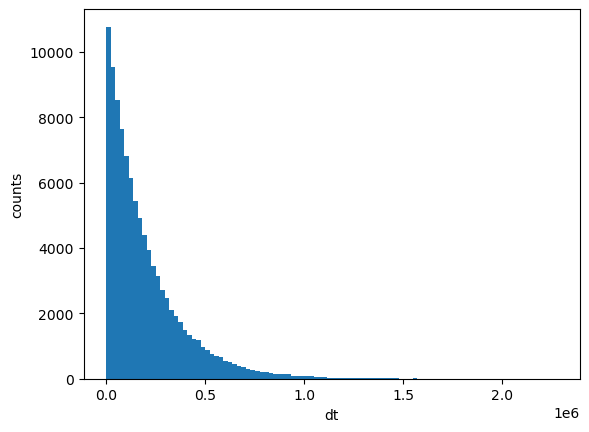

In [12]:
plt.hist(dt, bins=100, log=False)
plt.xlabel("dt")
plt.ylabel("counts")
plt.show()

In [13]:
np.quantile(dt, 0.99)

np.float64(923320.9399999995)

In [14]:
dr_list = []

for _, g in grouped:
    if len(g) == 2:
        dx = g["x"].values
        dy = g["y"].values
        dz = g["z"].values
        
        dr = np.sqrt((dx[0]-dx[1])**2+(dy[0]-dy[1])**2+(dz[0]-dz[1])**2)
        
        dr_list.append(dr)

dr = np.array(dr_list)

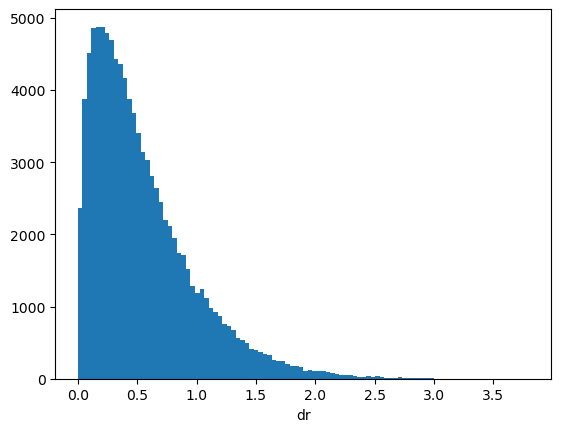

In [15]:
plt.hist(dr, bins=100, log=False)
plt.xlabel("dr")
plt.show()

In [16]:
np.quantile(dr, 0.99)

np.float64(1.9782516128214371)

In [32]:
import numpy as np
from scipy.special import digamma
from scipy.optimize import root
from scipy.stats import gamma

m1 = np.mean(dr)
m2 = np.mean(np.log(dr))

def equations(vars):
    alpha, beta = vars
    
    eq1 = alpha / beta - m1
    eq2 = digamma(alpha) - np.log(beta) - m2
    
    return [eq1, eq2]

sol = root(equations, [1.0, 1.0])

alpha, beta = sol.x

print("alpha =", alpha)
print("beta  =", beta)

alpha = 1.5346494189107145
beta  = 2.7964461046999296


In [35]:
pdf = gamma(a=alpha, scale=1/beta)

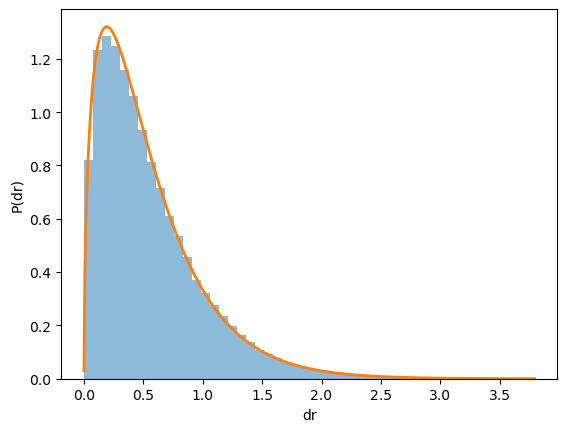

In [36]:

x = np.linspace(dr.min(), dr.max(), 500)

plt.hist(dr, bins=50, density=True, alpha=0.5)

plt.plot(x, pdf.pdf(x), lw=2)

plt.xlabel("dr")
plt.ylabel("P(dr)")
plt.show()

In [44]:
df['pair_id'].unique()

array([   -1,     0,     1, ..., 99997, 99998, 99999], shape=(100001,))

### DATASET pairs generation

In [12]:
import polars as pl
import numpy as np

from numba import njit
from tqdm import tqdm

EVENTS_FILE = "events.parquet"
TRUTH_FILE  = "truth.parquet"
FULL_OUTPUT_FILE = "pair_dataset_full.parquet"
OUTPUT_FILE = "pair_dataset.parquet"

MAX_DT = 2e6     # ns
MAX_DR = 4.         # metri


C = 299792458.0
n_w = 1.33

Vl = C/n_w

eps = 1e-12

events = pl.read_parquet(EVENTS_FILE)
truth = pl.read_parquet(TRUTH_FILE)

#Merging truth information in events dataframe

df = events.with_columns([
    truth["pair_id"],
    truth["label"],
    truth["label_name"]
])

#trasformation in cylinfdrical

df = df.with_columns([((pl.col("x")**2 + pl.col("y")**2).sqrt()).alias("r"), pl.arctan2(pl.col("y"),pl.col("x")).alias("phi")])
df = df.sort("time")

time = df["time"].to_numpy()

x = df["x"].to_numpy()
y = df["y"].to_numpy()
z = df["z"].to_numpy()

r = df["r"].to_numpy()
phi = df["phi"].to_numpy()

energy = df["energy"].to_numpy()
label = df["label"].to_numpy()
pair_id = df["pair_id"].to_numpy()

# Pair builder: we have slidinding temporal window in a given max dt trough numba
@njit
def build_pairs(time, x, y, z, max_dt, max_dr):
    
    n = len(time)
    max_dr2 = max_dr * max_dr
    pairs_i = []
    pairs_j = []
    j = 0

    for i in range(n):
        while j < n and (time[j] - time[i]) <= max_dt:
            j += 1
        for k in range(i + 1, j):
            dx = x[k] - x[i]
            dy = y[k] - y[i]
            dz = z[k] - z[i]

            dr2 = dx*dx + dy*dy + dz*dz
            
            # spatial cut
            if dr2 <= max_dr2:
                pairs_i.append(i)
                pairs_j.append(k)

    return np.array(pairs_i), np.array(pairs_j)

pi1, pj1 = build_pairs(time, x, y, z, MAX_DT, MAX_DR)
label_i = label[pi1]
label_j = label[pj1]

pi= pi1.copy()
pj = pj1.copy()

# caso da invertire:
# i ha label 2 e j ha label 1
swap_mask = (label_i == 2) & (label_j == 1)

# swap degli indici
pi[swap_mask], pj[swap_mask] = (pj[swap_mask],pi[swap_mask].copy())

# aggiorno label dopo swap
label_i = label[pi]
label_j = label[pj]

# energie coerenti
E1 = energy[pi]
E2 = energy[pj]
print(f"Number of candidate pairs: {len(pi):,}")


dt = time[pj] - time[pi]
# ns -> seconds
dt_sec = dt * 1e-9

dx = x[pj] - x[pi]
dy = y[pj] - y[pi]
dz = z[pj] - z[pi]

dr = np.sqrt(dx**2 + dy**2 + dz**2)

# cylindrical distance
dr_cyl = np.sqrt((r[pj] - r[pi])**2 +dz**2)

# angular distance
dphi = phi[pj] - phi[pi]

# angular wrapping
dphi = np.arctan2(np.sin(dphi),np.cos(dphi))

#Relativistic features

ds2 = (C*dt_sec)**2 - dr**2
beta_eff = dr / (C*dt_sec + eps)

# cherenkov check
dt_expected = dr / Vl
time_residual = dt_sec - dt_expected

#E1 = energy[pi]
#E2 = energy[pj]

E_sum  = E1 + E2
E_diff = np.abs(E1 - E2)

E_ratio = E1 / (E2 + eps)


target = ((pair_id[pi] != -1) & (pair_id[pi] == pair_id[pj])).astype(np.int8)


pair_df = pl.DataFrame({
    "i": pi,
    "j": pj,

    "dt": dt,
    

    "dr": dr,
    

    "dr_cyl": dr_cyl,

    "dx": dx,
    "dy": dy,
    "dz": dz,

    "dphi": dphi,

    "ds2": ds2,
    "beta_eff": beta_eff,

    "time_residual": time_residual,

    "r1": r[pi],
    "r2": r[pj],

    "z1": z[pi],
    "z2": z[pj],

    "E1": E1,
    "E2": E2,

    "E_sum": E_sum,
    "E_diff": E_diff,
    "E_ratio": E_ratio,
    "label1": label[pi],
    "label2": label[pj],
    "target": target
})




Number of candidate pairs: 201,515


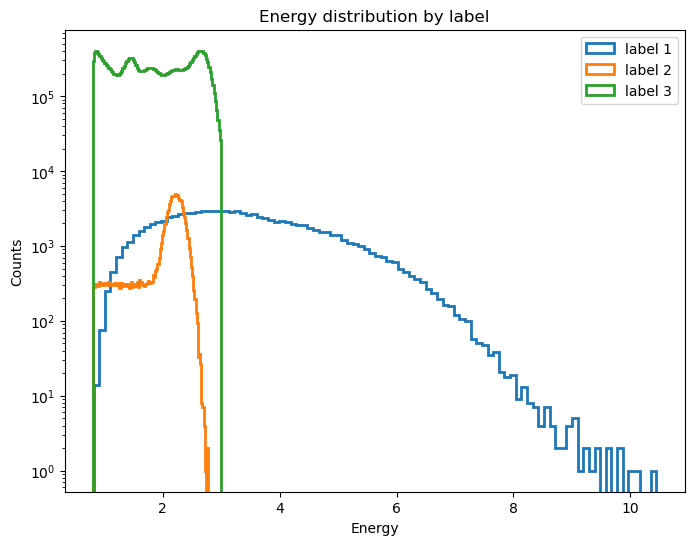

In [6]:
import matplotlib.pyplot as plt

labels_unique = np.unique(label)

plt.figure(figsize=(8,6))

for lab in labels_unique:
    
    mask = label == lab
    
    plt.hist(
        energy[mask],
        bins=100,
        histtype="step",
        linewidth=2,
        label=f"label {lab}",
        log=True
    )

plt.xlabel("Energy")
plt.ylabel("Counts")
plt.title("Energy distribution by label")
plt.legend()

plt.show()

In [7]:
pair_df.write_parquet(FULL_OUTPUT_FILE,compression="zstd")

signal_df = pair_df.filter(pl.col("target") == 1)

background_df = pair_df.filter(pl.col("target") == 0)

BKG_RATIO = 0.5
n_signal = signal_df.height

background_df = background_df.sample(n=min(background_df.height,n_signal * BKG_RATIO),seed=42)


pair_df_balanced = pl.concat([signal_df,background_df]).sample(fraction=1.0,seed=42)

BALANCED_OUTPUT_FILE = "pair_dataset_balanced.parquet"

pair_df_balanced.write_parquet(BALANCED_OUTPUT_FILE,compression="zstd")


print(pair_df)

print("\nShape:")
print(pair_df.shape)

print("\nSignal fraction:")
print(pair_df["target"].mean())


print(pair_df_balanced)

print("\nShape:")
print(pair_df_balanced.shape)

print("\nSignal fraction:")
print(pair_df_balanced["target"].mean())

shape: (201_515, 24)
┌──────────┬──────────┬─────────┬──────────┬───┬──────────┬────────┬────────┬────────┐
│ i        ┆ j        ┆ dt      ┆ dr       ┆ … ┆ E_ratio  ┆ label1 ┆ label2 ┆ target │
│ ---      ┆ ---      ┆ ---     ┆ ---      ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---    │
│ i64      ┆ i64      ┆ i64     ┆ f64      ┆   ┆ f64      ┆ i64    ┆ i64    ┆ i8     │
╞══════════╪══════════╪═════════╪══════════╪═══╪══════════╪════════╪════════╪════════╡
│ 163      ┆ 164      ┆ 322677  ┆ 0.413361 ┆ … ┆ 3.132235 ┆ 1      ┆ 2      ┆ 1      │
│ 407      ┆ 408      ┆ 147423  ┆ 1.338004 ┆ … ┆ 2.085203 ┆ 1      ┆ 2      ┆ 1      │
│ 425      ┆ 426      ┆ 71049   ┆ 0.477637 ┆ … ┆ 4.715027 ┆ 1      ┆ 2      ┆ 1      │
│ 440      ┆ 441      ┆ 145474  ┆ 0.111677 ┆ … ┆ 1.431577 ┆ 1      ┆ 2      ┆ 1      │
│ 531      ┆ 532      ┆ 1369491 ┆ 2.92571  ┆ … ┆ 0.966458 ┆ 3      ┆ 3      ┆ 0      │
│ …        ┆ …        ┆ …       ┆ …        ┆ … ┆ …        ┆ …      ┆ …      ┆ …      │
│ 25042303 ┆ 25042304 

In [16]:
sss= truth.filter(pl.col("pair_id") != -1)
rumorss= truth.filter(pl.col("pair_id") == -1)
rr=sss.height/rumorss.height
print(f"Original fraction of pairs in the first dataset: {rr}")

Original fraction of pairs in the first dataset: 0.008050461257215579


In [17]:
gain_full = pair_df["target"].mean()/rr
gain_balanced = pair_df_balanced["target"].mean()/rr
print(f"Gain trogh the full pair dataset: {gain_full}")
print(f"Gain trogh the balanced pair dataset: {gain_balanced}")

Gain trogh the full pair dataset: 61.63884392754881
Gain trogh the balanced pair dataset: 82.81098999999999


### Subsets creation

In [8]:
pair_df = pl.read_parquet("pair_dataset_full.parquet")

R_FID = 1.221
Z_FID = 1.271  # edge_radius + 0.05

pair_df = pair_df.with_columns([
    (
        (pl.col("r1") > R_FID) | (pl.col("r2") > R_FID) |
        (pl.col("z1").abs() > Z_FID) | (pl.col("z2").abs() > Z_FID)
    ).alias("is_edge")
])

fiducial_df = pair_df.filter(pl.col("is_edge") == False)
edge_df     = pair_df.filter(pl.col("is_edge") == True)

print(f"Full     : {pair_df.shape}    signal fraction: {pair_df['target'].mean():.4f}")
print(f"Fiducial : {fiducial_df.shape} signal fraction: {fiducial_df['target'].mean():.4f}")
print(f"Edge     : {edge_df.shape}    signal fraction: {edge_df['target'].mean():.4f}")

# split sugli indici i (prompt events)
prompt_events = np.unique(pair_df["i"].to_numpy())
print(f"\nUnique prompt events: {len(prompt_events):,}")

train_events, temp_events = train_test_split(prompt_events, test_size=0.20, random_state=42)
val_events,   test_events = train_test_split(temp_events,   test_size=0.50, random_state=42)

print(f"Train: {len(train_events):,}  Val: {len(val_events):,}  Test: {len(test_events):,}")

train_set = set(train_events)
val_set   = set(val_events)
test_set  = set(test_events)

def split_by_i(df, event_set):
    mask = np.isin(df["i"].to_numpy(), list(event_set))
    return df.filter(mask)

full_train = split_by_i(pair_df,     train_set)
full_val   = split_by_i(pair_df,     val_set)
full_test  = split_by_i(pair_df,     test_set)

fid_train  = split_by_i(fiducial_df, train_set)
fid_val    = split_by_i(fiducial_df, val_set)
fid_test   = split_by_i(fiducial_df, test_set)

edge_train = split_by_i(edge_df,     train_set)
edge_val   = split_by_i(edge_df,     val_set)
edge_test  = split_by_i(edge_df,     test_set)

for name, df in [
    ("full_train", full_train), ("full_val", full_val), ("full_test", full_test),
    ("fid_train",  fid_train),  ("fid_val",  fid_val),  ("fid_test",  fid_test),
    ("edge_train", edge_train), ("edge_val", edge_val), ("edge_test", edge_test),
]:
    print(f"{name:12s}: {df.shape[0]:>8,} coppie  signal={df['target'].mean():.4f}")

full_train.write_parquet("full_train.parquet")
full_val.write_parquet("full_val.parquet")
full_test.write_parquet("full_test.parquet")

fid_train.write_parquet("fid_train.parquet")
fid_val.write_parquet("fid_val.parquet")
fid_test.write_parquet("fid_test.parquet")

edge_train.write_parquet("edge_train.parquet")
edge_val.write_parquet("edge_val.parquet")
edge_test.write_parquet("edge_test.parquet")

Full     : (201515, 25)    signal fraction: 0.4962
Fiducial : (43944, 25) signal fraction: 0.9641
Edge     : (157571, 25)    signal fraction: 0.3657

Unique prompt events: 200,507
Train: 160,405  Val: 20,051  Test: 20,051
full_train  :  161,193 coppie  signal=0.4973
full_val    :   20,155 coppie  signal=0.4918
full_test   :   20,167 coppie  signal=0.4916
fid_train   :   35,081 coppie  signal=0.9646
fid_val     :    4,394 coppie  signal=0.9609
fid_test    :    4,469 coppie  signal=0.9633
edge_train  :  126,112 coppie  signal=0.3674
edge_val    :   15,761 coppie  signal=0.3610
edge_test   :   15,698 coppie  signal=0.3574


### SHIFT datasets

In [17]:
import numpy as np
import polars as pl
from numba import njit

C    = 299792458.0
n_w  = 1.33
Vl   = C / n_w        # velocità luce in acqua, coerente col dataset originale
eps  = 1e-12
MAX_DT = 2e6
MAX_DR = 2.5
SHIFT  = 10 * MAX_DT  # 20 ms >> 2 ms → zero coppie reali

# dataset originale (già sorted per time)
time    = df["time"].to_numpy()
x       = df["x"].to_numpy()
y       = df["y"].to_numpy()
z       = df["z"].to_numpy()
r       = df["r"].to_numpy()
phi     = df["phi"].to_numpy()
energy  = df["energy"].to_numpy()
label   = df["label"].to_numpy()
pair_id = df["pair_id"].to_numpy()

# dataset shiftato: stesso clone, time traslato indietro di SHIFT
#time2 = time - SHIFT   # shift indietro → time2[j] < time[i] → dt = time2[j]-time[i] ~ -SHIFT+small

@njit
def build_pairs_bkg(time, time2, x, y, z, max_dt, max_dr):
    n1    = len(time)
    n2    = len(time2)
    max_dr2 = max_dr * max_dr
    pairs_i = []
    pairs_j = []
    j = 0
    for i in range(n1):
        while j < n2 and time2[j] < time[i] - max_dt:
            j += 1
        k = j
        while k < n2 and time2[k] <= time[i] + max_dt:
            if k != i:
                dx = x[k] - x[i]
                dy = y[k] - y[i]
                dz = z[k] - z[i]
                if dx*dx + dy*dy + dz*dz <= max_dr2:
                    pairs_i.append(i)
                    pairs_j.append(k)
            k += 1
    return np.array(pairs_i), np.array(pairs_j)

SHIFTS = np.linspace(2,20,10)   

all_shifted = []

for shift_mult in SHIFTS:

    SHIFT = 1e6*shift_mult
    time2 = time - SHIFT

    pi, pj = build_pairs_bkg(time, time2, x, y, z, MAX_DT, MAX_DR)
    print(f"shift={shift_mult}×MAX_DT → {len(pi):,} coppie")

    dt       = time2[pj] - time[pi]
    dt_sec   = dt * 1e-9
    dx       = x[pj] - x[pi]
    dy       = y[pj] - y[pi]
    dz       = z[pj] - z[pi]
    dr       = np.sqrt(dx**2 + dy**2 + dz**2)
    dr_cyl   = np.sqrt((r[pj] - r[pi])**2 + dz**2)
    dphi     = np.arctan2(np.sin(phi[pj] - phi[pi]), np.cos(phi[pj] - phi[pi]))
    ds2      = (C * dt_sec)**2 - dr**2
    beta_eff = dr / (C * np.abs(dt_sec) + eps)
    time_residual = dt_sec - dr / Vl
    E1 = energy[pi];  E2 = energy[pj]

    all_shifted.append(pl.DataFrame({
        "shift_id": np.full(len(pi), shift_mult, dtype=np.int8),
        "i": pi, "j": pj,
        "dt": dt, "dr": dr, "dr_cyl": dr_cyl,
        "dx": dx, "dy": dy, "dz": dz, "dphi": dphi,
        "ds2": ds2, "beta_eff": beta_eff, "time_residual": time_residual,
        "r1": r[pi],  "r2": r[pj],
        "z1": z[pi],  "z2": z[pj],
        "E1": E1, "E2": E2,
        "E_sum": E1+E2, "E_diff": np.abs(E1-E2), "E_ratio": E1/(E2+eps),
        "label1": label[pi], "label2": label[pj],
        "target": np.zeros(len(pi), dtype=np.int8)
    }))

pair_df2 = pl.concat(all_shifted)
print(f"\nTotale shifted: {pair_df2.shape}")
print(f"Coppie per shift_id:\n{pair_df2.group_by('shift_id').len().sort('shift_id')}")

pair_df2.write_parquet("shifted_dataset.parquet", compression="zstd")

shift=2.0×MAX_DT → 222,344 coppie
shift=4.0×MAX_DT → 122,509 coppie
shift=6.0×MAX_DT → 123,072 coppie
shift=8.0×MAX_DT → 123,128 coppie
shift=10.0×MAX_DT → 123,019 coppie
shift=12.0×MAX_DT → 123,432 coppie
shift=14.0×MAX_DT → 123,698 coppie
shift=16.0×MAX_DT → 123,125 coppie
shift=18.0×MAX_DT → 122,455 coppie
shift=20.0×MAX_DT → 122,829 coppie

Totale shifted: (1329611, 25)
Coppie per shift_id:
shape: (10, 2)
┌──────────┬────────┐
│ shift_id ┆ len    │
│ ---      ┆ ---    │
│ i8       ┆ u32    │
╞══════════╪════════╡
│ 2        ┆ 222344 │
│ 4        ┆ 122509 │
│ 6        ┆ 123072 │
│ 8        ┆ 123128 │
│ 10       ┆ 123019 │
│ 12       ┆ 123432 │
│ 14       ┆ 123698 │
│ 16       ┆ 123125 │
│ 18       ┆ 122455 │
│ 20       ┆ 122829 │
└──────────┴────────┘


In [18]:
pair_df2 = pl.read_parquet("shifted_dataset.parquet")
R_D = 1.5
Z_D = 1.55

# margine dal bordo
edge = 0.30
edge_radius=1.221 # look at laura.ypnb local mio last cell
# regione fiducial
#R_FID = R_D - edge
#Z_FID = Z_D - edge
R_FID=edge_radius
Z_FID =edge_radius+0.05
pair_df2 = pair_df2.with_columns([((pl.col("r1") > R_FID) | (pl.col("r2") > R_FID) |(pl.col("z1").abs() > Z_FID) | (pl.col("z2").abs() > Z_FID)).alias("is_edge")])
def split_by_i(df, event_set):
    mask = np.isin(df["i"].to_numpy(), list(event_set))
    return df.filter(mask)

# eventi unici
unique_i = np.unique(pair_df2["i"].to_numpy())

# train 70%, temp 30%
train_ids, temp_ids = train_test_split(unique_i, test_size=0.30, random_state=42, shuffle=True)

# val 15%, test 15%
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42, shuffle=True)

# trasformo in set (più veloce per isin)
train_set = set(train_ids)
val_set   = set(val_ids)
test_set  = set(test_ids)

print(len(train_set), len(val_set), len(test_set))
# split per shift_id in modo da avere test set separati per shift
# ma usando lo stesso train/val/test split sugli eventi i
full_test2  = split_by_i(pair_df2, test_set)
full_train2 = split_by_i(pair_df2, train_set)
full_val2   = split_by_i(pair_df2, val_set)

print(f"full_test2 : {full_test2.shape}")
print(f"Coppie per shift nel test:\n{full_test2.group_by('shift_id').len().sort('shift_id')}")

full_train2.write_parquet("full_train2.parquet")
full_val2.write_parquet("full_val2.parquet")
full_test2.write_parquet("full_test2.parquet")

532600 114129 114129
full_test2 : (199430, 26)
Coppie per shift nel test:
shape: (10, 2)
┌──────────┬───────┐
│ shift_id ┆ len   │
│ ---      ┆ ---   │
│ i8       ┆ u32   │
╞══════════╪═══════╡
│ 2        ┆ 33580 │
│ 4        ┆ 18348 │
│ 6        ┆ 18341 │
│ 8        ┆ 18444 │
│ 10       ┆ 18395 │
│ 12       ┆ 18398 │
│ 14       ┆ 18501 │
│ 16       ┆ 18556 │
│ 18       ┆ 18426 │
│ 20       ┆ 18441 │
└──────────┴───────┘


### OLD dataset

In [22]:
import numpy as np
import polars as pl
from numba import njit

# clone + shift temporale
df2 = df.clone().with_columns((pl.col("time") - 2e6).alias("time"))

# arrays df
time = df["time"].to_numpy()

x = df["x"].to_numpy()
y = df["y"].to_numpy()
z = df["z"].to_numpy()
r = df["r"].to_numpy()

phi = df["phi"].to_numpy()
energy = df["energy"].to_numpy()
label = df["label"].to_numpy()
pair_id = df["pair_id"].to_numpy()

# arrays df2
time2 = df2["time"].to_numpy()

x2 = df2["x"].to_numpy()
y2 = df2["y"].to_numpy()
z2 = df2["z"].to_numpy()
r2 = df2["r"].to_numpy()

phi2 = df2["phi"].to_numpy()
energy2 = df2["energy"].to_numpy()
label2 = df2["label"].to_numpy()
pair_id2 = df2["pair_id"].to_numpy()

max_dt = 2e6
max_dr = 4.0
#SHIFT = 10e6  # 10 ms >> max_dt = 2 ms → nessuna coppia è reale

#time2 = time - SHIFT  # shift indietro

@njit
def build_pairs_bkg(time, time2, x, y, z, x2, y2, z2, max_dt, max_dr):
    n1 = len(time)
    n2 = len(time2)
    max_dr2 = max_dr * max_dr
    pairs_i = []
    pairs_j = []
    j = 0

    for i in range(n1):
        # avanza j finché time2[j] < time[i] - max_dt (fuori finestra sinistra)
        while j < n2 and time2[j] < time[i] - max_dt:
            j += 1
        # ora time2[j] >= time[i] - max_dt
        # raccoglie tutti i j con |time[i] - time2[j]| <= max_dt
        k = j
        while k < n2 and time2[k] <= time[i] + max_dt:
            if k != i:  # evita auto-coppie (stesso indice)
                dx = x2[k] - x[i]
                dy = y2[k] - y[i]
                dz = z2[k] - z[i]
                if dx*dx + dy*dy + dz*dz <= max_dr2:
                    pairs_i.append(i)
                    pairs_j.append(k)
            k += 1

    return np.array(pairs_i), np.array(pairs_j)

pi, pj = build_pairs_bkg(time, time2, x, y, z, x2, y2, z2, max_dt, max_dr)
print(f"Background candidate pairs: {len(pi):,}")
"""@njit
def build_pairs(time, time2, x, y, z, x2, y2, z2, max_dt, max_dr):
    n = len(time)

    max_dr2 = max_dr * max_dr

    pairs_i = []
    pairs_j = []

    j = 0

    for i in range(n):

        # stessa logica del codice originale
        while j < n and (time2[j] - time[i]) <= max_dt:
            j += 1

        # coppie nella finestra
        for k in range(i + 1, j):

            dx = x2[k] - x[i]
            dy = y2[k] - y[i]
            dz = z2[k] - z[i]

            dr2 = dx*dx + dy*dy + dz*dz

            if dr2 <= max_dr2:
                pairs_i.append(i)
                pairs_j.append(k)

    return np.array(pairs_i), np.array(pairs_j)

# build candidate pairs
#pi, pj = build_pairs(time, time2, x, y, z, x2, y2, z2, max_dt, max_dr)

# build_pairs: cerca coppie (i da df, j da df2) con time2[j] > time[i]
pi, pj = build_pairs(time, time2, x, y, z, x2, y2, z2, max_dt, max_dr)
"""
# features COERENTI con il dataset originale: j - i
dt = time2[pj] - time[pi]   # sempre positivo, come nell'originale
dt_sec = dt * 1e-9

dx = x2[pj] - x[pi]
dy = y2[pj] - y[pi]
dz = z2[pj] - z[pi]

dr = np.sqrt(dx**2 + dy**2 + dz**2)

ds2 = (C * dt_sec)**2 - dr**2
beta_eff = dr / (C * dt_sec + eps)          
dt_expected = dr / Vl
time_residual = dt_sec - dt_expected         


target = np.zeros(len(pi), dtype=np.int8)   



# features
eps = 1e-12
C = 299792458.0
Vl = C/n_w

E1 = energy[pi]
E2 = energy2[pj]


dr_cyl = np.sqrt((r[pi] - r2[pj])**2 + dz**2)

dphi = phi2[pj]- phi[pi] 
dphi = np.arctan2(np.sin(dphi), np.cos(dphi))




E_sum = E1 + E2
E_diff = np.abs(E1 - E2)
E_ratio = E1 / (E2 + eps)


pair_df2 = pl.DataFrame({
    "i": pi,
    "j": pj,

    "dt": dt,

    "dr": dr,
    "dr_cyl": dr_cyl,

    "dx": dx,
    "dy": dy,
    "dz": dz,

    "dphi": dphi,

    "ds2": ds2,
    "beta_eff": beta_eff,

    "time_residual": time_residual,

    "r1": r[pi],
    "r2": r2[pj],

    "z1": z[pi],
    "z2": z2[pj],

    "E1": E1,
    "E2": E2,

    "E_sum": E_sum,
    "E_diff": E_diff,
    "E_ratio": E_ratio,

    "label1": label[pi],
    "label2": label2[pj],

    "target": target
})

Background candidate pairs: 302,584


In [23]:
pair_df2.write_parquet("shifted_dataset2.parquet",compression="zstd")

signal_df2 = pair_df2.filter(pl.col("target") == 1)

background_df2 = pair_df2.filter(pl.col("target") == 0)

BKG_RATIO = 0.5
n_signal = signal_df2.height

background_df2 = background_df2.sample(n=min(background_df2.height,n_signal * BKG_RATIO),seed=42)


pair_df_balanced2 = pl.concat([signal_df2,background_df2]).sample(fraction=1.0,seed=42)

BALANCED_OUTPUT_FILE = "pair_dataset_balanced2.parquet"

pair_df_balanced2.write_parquet(BALANCED_OUTPUT_FILE,compression="zstd")


print(pair_df2)

print("\nShape:")
print(pair_df2.shape)

print("\nSignal fraction:")
print(pair_df2["target"].mean())


print(pair_df_balanced2)

print("\nShape:")
print(pair_df_balanced2.shape)

print("\nSignal fraction:")
print(pair_df_balanced2["target"].mean())

shape: (302_584, 24)
┌──────────┬──────────┬─────────────┬──────────┬───┬──────────┬────────┬────────┬────────┐
│ i        ┆ j        ┆ dt          ┆ dr       ┆ … ┆ E_ratio  ┆ label1 ┆ label2 ┆ target │
│ ---      ┆ ---      ┆ ---         ┆ ---      ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---    │
│ i64      ┆ i64      ┆ f64         ┆ f64      ┆   ┆ f64      ┆ i64    ┆ i64    ┆ i8     │
╞══════════╪══════════╪═════════════╪══════════╪═══╪══════════╪════════╪════════╪════════╡
│ 44       ┆ 45       ┆ 1.52775e6   ┆ 1.297443 ┆ … ┆ 0.78124  ┆ 3      ┆ 3      ┆ 0      │
│ 61       ┆ 62       ┆ 1.599325e6  ┆ 3.057745 ┆ … ┆ 0.940053 ┆ 3      ┆ 3      ┆ 0      │
│ 126      ┆ 127      ┆ 1.404688e6  ┆ 3.059215 ┆ … ┆ 1.563871 ┆ 3      ┆ 3      ┆ 0      │
│ 130      ┆ 131      ┆ 615326.0    ┆ 1.041213 ┆ … ┆ 1.061588 ┆ 3      ┆ 3      ┆ 0      │
│ 163      ┆ 164      ┆ -1.677323e6 ┆ 0.413361 ┆ … ┆ 3.132235 ┆ 1      ┆ 2      ┆ 0      │
│ …        ┆ …        ┆ …           ┆ …        ┆ … ┆ …        ┆ …    

In [24]:
pair_df2 = pl.read_parquet("shifted_dataset2.parquet")

pair_df2 = pair_df2.with_columns([
    (
        (pl.col("r1") > R_FID) | (pl.col("r2") > R_FID) |
        (pl.col("z1").abs() > Z_FID) | (pl.col("z2").abs() > Z_FID)
    ).alias("is_edge")
])

fiducial_df2 = pair_df2.filter(pl.col("is_edge") == False)
edge_df2     = pair_df2.filter(pl.col("is_edge") == True)

print(f"Full     : {pair_df2.shape}    signal fraction: {pair_df2['target'].mean():.4f}")
print(f"Fiducial : {fiducial_df2.shape} signal fraction: {fiducial_df2['target'].mean():.4f}")
print(f"Edge     : {edge_df2.shape}    signal fraction: {edge_df2['target'].mean():.4f}")

# riusa lo stesso split sugli i del dataset originale: stessi eventi, stesso random state
# (gli indici i nello shifted si riferiscono agli stessi eventi originali)
prompt_events2 = np.unique(pair_df2["i"].to_numpy())
print(f"\nUnique prompt events (shifted): {len(prompt_events2):,}")

train_events2, temp_events2 = train_test_split(prompt_events2, test_size=0.20, random_state=42)
val_events2,   test_events2 = train_test_split(temp_events2,   test_size=0.50, random_state=42)

train_set2 = set(train_events2)
val_set2   = set(val_events2)
test_set2  = set(test_events2)

full_train2 = split_by_i(pair_df2,     train_set2)
full_val2   = split_by_i(pair_df2,     val_set2)
full_test2  = split_by_i(pair_df2,     test_set2)

fid_train2  = split_by_i(fiducial_df2, train_set2)
fid_val2    = split_by_i(fiducial_df2, val_set2)
fid_test2   = split_by_i(fiducial_df2, test_set2)

edge_train2 = split_by_i(edge_df2,     train_set2)
edge_val2   = split_by_i(edge_df2,     val_set2)
edge_test2  = split_by_i(edge_df2,     test_set2)

for name, df in [
    ("full_train2", full_train2), ("full_val2", full_val2), ("full_test2", full_test2),
    ("fid_train2",  fid_train2),  ("fid_val2",  fid_val2),  ("fid_test2",  fid_test2),
    ("edge_train2", edge_train2), ("edge_val2", edge_val2), ("edge_test2", edge_test2),
]:
    print(f"{name:13s}: {df.shape[0]:>8,} coppie  signal={df['target'].mean():.4f}")

full_train2.write_parquet("full_train22.parquet")
full_val2.write_parquet("full_val22.parquet")
full_test2.write_parquet("full_test22.parquet")

fid_train2.write_parquet("fid_train22.parquet")
fid_val2.write_parquet("fid_val22.parquet")
fid_test2.write_parquet("fid_test22.parquet")

edge_train2.write_parquet("edge_train22.parquet")
edge_val2.write_parquet("edge_val22.parquet")
edge_test2.write_parquet("edge_test22.parquet")

Full     : (302584, 25)    signal fraction: 0.0000
Fiducial : (45551, 25) signal fraction: 0.0000
Edge     : (257033, 25)    signal fraction: 0.0000

Unique prompt events (shifted): 300,135
full_train2  :  242,080 coppie  signal=0.0000
full_val2    :   30,268 coppie  signal=0.0000
full_test2   :   30,236 coppie  signal=0.0000
fid_train2   :   36,431 coppie  signal=0.0000
fid_val2     :    4,638 coppie  signal=0.0000
fid_test2    :    4,482 coppie  signal=0.0000
edge_train2  :  205,649 coppie  signal=0.0000
edge_val2    :   25,630 coppie  signal=0.0000
edge_test2   :   25,754 coppie  signal=0.0000


In [20]:
#pair_df = pl.read_parquet("pair_dataset_full.parquet")


R_D = 1.5
Z_D = 1.55

# margine dal bordo
edge = 0.30
edge_radius=1.221 # look at laura.ypnb local mio last cell
# regione fiducial
#R_FID = R_D - edge
#Z_FID = Z_D - edge
R_FID=edge_radius
Z_FID =edge_radius+0.05
print("\nFiducial volume:")
print("R_FID =", R_FID)
print("Z_FID =", Z_FID)

pair_df2 = pair_df2.with_columns([((pl.col("r1") > R_FID)|(pl.col("r2") > R_FID)|(pl.col("z1").abs() > Z_FID)|(pl.col("z2").abs() > Z_FID)).alias("is_edge")])

fiducial_df2 = pair_df2.filter(pl.col("is_edge") == False)

edge_df2 = pair_df2.filter(pl.col("is_edge") == True)


print(pair_df2.shape)

print("\nSignal full fraction:")
print(pair_df2["target"].mean())

print(fiducial_df2.shape)

print("\nSignal fiducial fraction:")
print(fiducial_df2["target"].mean())

print(edge_df2.shape)

print("\nSignal edge fraction:")
print(edge_df2["target"].mean())


# split sugli eventi originali non sulle coppie
all_events2 = np.unique(np.concatenate([pair_df2["i"].to_numpy(),pair_df2["j"].to_numpy()]))

print("\nNumber of unique events:")
print(len(all_events2))

train_events2, temp_events2 = train_test_split(all_events2,test_size=0.20,random_state=42)

val_events2, test_events2 = train_test_split(temp_events2,test_size=0.50,random_state=42)

print("\nTrain events:", len(train_events2))
print("Val events:", len(val_events2))
print("Test events:", len(test_events2))


train_set2 = set(train_events2)
val_set2 = set(val_events2)
test_set2 = set(test_events2)

def split_pairs(df, event_set):

    i_mask = np.isin(df["i"].to_numpy(),list(event_set))

    j_mask = np.isin(df["j"].to_numpy(),list(event_set))

    mask = i_mask & j_mask

    return df.filter(mask)

full_train = split_pairs(pair_df2, train_set2)
full_val = split_pairs(pair_df2, val_set2)
full_test = split_pairs(pair_df2, test_set2)


fid_train = split_pairs(fiducial_df2, train_set2)
fid_val = split_pairs(fiducial_df2, val_set2)
fid_test = split_pairs(fiducial_df2, test_set2)


edge_train = split_pairs(edge_df2, train_set2)
edge_val = split_pairs(edge_df2, val_set2)
edge_test = split_pairs(edge_df2, test_set2)



# FULL
full_train.write_parquet("full_train2.parquet")
full_val.write_parquet("full_val2.parquet")
full_test.write_parquet("full_test2.parquet")

# FIDUCIAL
fid_train.write_parquet("fid_train2.parquet")
fid_val.write_parquet("fid_val2.parquet")
fid_test.write_parquet("fid_test2.parquet")

# EDGE
edge_train.write_parquet("edge_train2.parquet")
edge_val.write_parquet("edge_val2.parquet")
edge_test.write_parquet("edge_test2.parquet")



Fiducial volume:
R_FID = 1.221
Z_FID = 1.2710000000000001
(302584, 25)

Signal full fraction:
0.0
(45551, 25)

Signal fiducial fraction:
0.0
(257033, 25)

Signal edge fraction:
0.0

Number of unique events:
596938

Train events: 477550
Val events: 59694
Test events: 59694


In [14]:
len(full_)

2983

In [11]:
train_events2.write_parquet("full_train2.parquet")
val_events2.write_parquet("full_val2.parquet")
test_events2.write_parquet("full_test2.parquet")

AttributeError: 'numpy.ndarray' object has no attribute 'write_parquet'

302583